In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from torchvision.datasets import MNIST
from torchvision import transforms

In [2]:
#load the dataset
mnist = MNIST(root = './data', download = True, transform = transforms.ToTensor(), train = True)
x = mnist.data.numpy().reshape(-1, 28 * 28) / 255.0
y = mnist.targets.numpy()

x = x[:1000]
y = y[:1000]

100%|██████████| 9.91M/9.91M [00:14<00:00, 703kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 123kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.48MB/s]


In [3]:
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_encoded = one_hot(y)

In [4]:
#init weights and biases
np.random.seed(43)
input_size = 28 * 28
hidden_size = 128
output_size = 10

In [6]:
#create weights and biases of network
# W1: (784, 128), b1: (1, 128)
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

# W2: (128, 10), b2: (1, 10)
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

In [10]:
#activation funcs
def relu(x):
    return np.maximum(0,x)

def relu_derivative(x):
    return np.where(x > 0 , 1, 0)

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

In [8]:
#create cross entroup loss
def cross_entropy(pred, target):
    # L = =sum(y * log(y_hat))
    return -np.sum(target * np.log(pred + 1e-9)) / pred.shape[0]

In [14]:
#training loop
lr = 0.01
for epoch in range(100):
    #forward pass
    # z1 = X * W1 + b1
    z1 = np.dot(x, W1) + b1
    #relu layer
    a1 = relu(z1)
    #layer 2
    z2 = np.dot(a1, W2) + b2
    #softmax layer for output
    a2 = softmax(z2)
    #calc loss
    loss = cross_entropy(a2, y_encoded)
    if epoch % 5 == 0:
        print(f'Epoch {epoch}, Loss: {loss:.4f}')


    #backward pass
    # ∂L/∂z₂ = a₂ - Y
    dz2 = a2 - y_encoded  # (N × 10)

    # ∂L/∂W₂ = a₁ᵀ · dz₂
    dW2 = np.dot(a1.T, dz2) / x.shape[0] 

    # ∂L/∂b₂ = Σ dz₂
    db2 = np.sum(dz2, axis=0, keepdims=True) / x.shape[0]

    # ∂L/∂a₁ = dz₂ · W₂ᵀ
    da1 = np.dot(dz2, W2.T) 

    # ∂L/∂z₁ = da₁ ⊙ ReLU′(z₁)
    dz1 = da1 * relu_derivative(z1)

    # ∂L/∂W₁ = Xᵀ · dz₁
    dW1 = np.dot(x.T, dz1) / x.shape[0]  

    # ∂L/∂b₁ = Σ dz₁
    db1 = np.sum(dz1, axis=0, keepdims=True) / x.shape[0]


    #update params
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

Epoch 0, Loss: 2.3017
Epoch 5, Loss: 2.3012
Epoch 10, Loss: 2.3006
Epoch 15, Loss: 2.3000
Epoch 20, Loss: 2.2994
Epoch 25, Loss: 2.2988
Epoch 30, Loss: 2.2982
Epoch 35, Loss: 2.2976
Epoch 40, Loss: 2.2970
Epoch 45, Loss: 2.2963
Epoch 50, Loss: 2.2957
Epoch 55, Loss: 2.2950
Epoch 60, Loss: 2.2944
Epoch 65, Loss: 2.2937
Epoch 70, Loss: 2.2930
Epoch 75, Loss: 2.2922
Epoch 80, Loss: 2.2915
Epoch 85, Loss: 2.2907
Epoch 90, Loss: 2.2899
Epoch 95, Loss: 2.2891


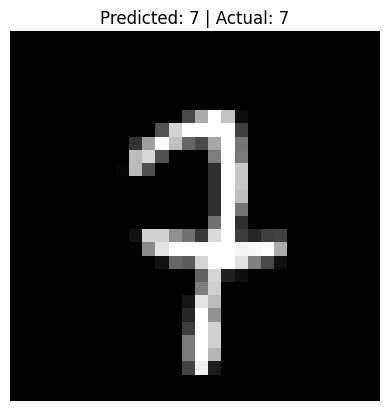

In [15]:
rand_idx = random.randint(0, x.shape[0] - 1)
img = x[rand_idx].reshape(1,-1)
z1 = np.dot(img, W1) + b1
a1 = relu(z1)
z2 = np.dot(a1, W2) + b2
pred = np.argmax(z2)

# Show result
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {pred} | Actual: {y[rand_idx]}")
plt.axis('off')
plt.show()
